# DANA 4830 Final Exam — master overview (Leo Sanchez)

**Submission PDF.** Entregar **`04_Analysis/2_0_final_overview.pdf`**, generado desde
**este notebook** (`03_Codes/2_0_final_overview.ipynb`). Los otros notebooks son detalle;
el profesor puede revisar solo el PDF (o este notebook ejecutado).

Para regenerar solo el entregable:
`python run_all.py --overview-pdf` desde `03_Codes/`.

Numbers come from saved CSVs in `04_Analysis` (not typed by hand).

```text
Rosati → DGE / biological evidence
        +
Syed → ML / predictive feature selection
        ↓
Candidate biomarkers → evaluation and external comparison
```


## Key terms used in this notebook

| Term | Simple explanation |
| ---- | ------------------ |
| Candidate biomarker | A gene with support in this analysis. Not a clinical test yet. |
| Transferability | Whether a panel from one disease still works in another. |
| Study-wise centering | Simple batch adjustment. Not ComBat. |

## Main methodological idea

DGE and machine learning answer related but different questions. DGE finds genes with
statistically important expression changes. ML feature selection finds genes that help
predict the class. Using both can shorten the candidate list and give two kinds of
evidence. Strong results in one dataset are not enough for clinical validation.

PCA is only a picture of variation. A VAE is optional and not used, because latent
variables would not be individual gene names.


## Task 1.1 — written comparison

Full ~300-word text is embedded below from `04_Analysis/task1_1_comparison.md`.

**Short idea:** Rosati = which genes change (limma here); Syed/Midterm = which subset predicts class.
The two pipelines **complement** each other: DGE narrows the biological search space under FDR control;
ML then shrinks to a compact predictive panel.

On GSE75214 we reached a **16-gene ML consensus panel** (all numeric expression features).
The LD1 teaching plot shows disease vs control largely separated on that panel, so **LDA with shrinkage**
was a natural linear baseline — **mean 5-fold CV ROC-AUC 0.9948** (SMOTE inside each fold).

**Dimensionality reduction.** PCA in Task 2.2 is exploratory only. A VAE is not used:
latent axes are not gene names.


## Setup

In [1]:
# We only load saved outputs here, so this notebook is fast and cannot drift from the data.
import pathlib
import pandas as pd
from IPython.display import Image, display

OUT = pathlib.Path("../04_Analysis")
FIG = OUT / "figures"
DATA = pathlib.Path("../01_Data")
pd.set_option("display.width", 120)

def show_fig(path, width=560):
    path = pathlib.Path(path)
    if path.exists():
        display(Image(str(path), width=width))
    else:
        print(f"Figure missing: {path}")

print("Loaded paths. Figures in", FIG)


Loaded paths. Figures in ..\04_Analysis\figures


## Notebook map

| Notebook | What it does |
|----------|--------------|
| `2_1_01_data_and_dge.ipynb` | GSE75214 load, skim, limma DGE, volcano, heatmap modules |
| `2_1_02_feature_selection.ipynb` | MI, RFECV, EN, GBC consensus panel (train-only SMOTE) |
| `2_1_03_evaluation_and_comparison.ipynb` | LDA/LR/RF CV, WELM/BWELM, enrichment, Midterm compare |
| `2_2_01_merge_datasets.ipynb` | Four GEO datasets, raw skim, merge, study-wise centering |
| `2_2_02_validate_pipelines.ipynb` | Cervical DGE, Wang 10/10, ML panel 47 genes |
| `2_0_final_overview.ipynb` | This master summary + oral defense |


In [2]:
task11 = (OUT / "task1_1_comparison.md").read_text(encoding="utf-8")
print(task11)


# Task 1.1 — Comparison of biomarker approaches (~300 words)

Rosati et al. (2024) review a statistics-first bioinformatics pipeline: quality
control, normalization, differential expression, multiple-testing control (FDR),
pathway enrichment, then ROC/AUC and, when follow-up exists, survival models. The
scientific question is *which genes are differentially expressed* and what biology
they point to. Depending on the assay, that DGE step may use edgeR (TMM + negative
binomial), DESeq2 (median-of-ratios + negative binomial), NOISeq, SAMseq, or limma
(linear models with empirical Bayes). GSE75214 is a microarray of log2 intensities,
not raw RNA-seq counts, so limma is the appropriate tool here; swapping in DESeq2
or edgeR would be methodologically wrong for this matrix.

Syed et al. (2024), which Midterm 1 replicated as `syed_pipeline`, ask a different
question: *which small subset best predicts class*? After DEG filtering, four
feature-selection methods (mutual information, RFECV, elasti

In [3]:
# Headline metrics computed from saved analysis tables (not typed by hand).
import json
import pandas as pd
from pathlib import Path
from IPython.display import display

dge1 = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
deg1 = dge1[dge1["DEG"]]
ml1_n = len(pd.read_csv(OUT / "ml_biomarkers_2_1.csv", index_col=0))
master = pd.read_csv(DATA / "cervical_master.csv")
dge2 = pd.read_csv(OUT / "cervical_dge_table.csv", index_col=0)
strict2 = (dge2["FDR"] < 0.05) & (dge2["log2FC"].abs() >= 1.5)
cdeg2 = dge2[strict2]
ml2_n = len(pd.read_csv(OUT / "cervical_ml_panel.csv", index_col=0))
wang_hub = ["CDK1", "CDC20", "AURKA", "TOP2A", "ASPM", "NCAPG", "KIF23", "CENPF", "KIF20A", "PRC1"]
wang_rec = sum(1 for g in wang_hub if g in dge2.index and bool(strict2.loc[g]))

rows = [
    ("GSE75214 DEGs (|log2FC|>=1.0)", int(deg1.shape[0])),
    ("GSE75214 DEGs (|log2FC|>=1.5)", int(((dge1["FDR"] < 0.05) & (dge1["log2FC"].abs() >= 1.5)).sum())),
    ("GSE75214 ML panel genes", ml1_n),
    ("Master samples", master.shape[0]),
    ("Master common genes", master.shape[1] - 2),
    ("Master DEGs (|log2FC|>=1.5)", int(cdeg2.shape[0])),
    ("Master ML panel genes", ml2_n),
    ("Wang hub genes recovered", f"{wang_rec}/10"),
]
summary = pd.DataFrame(rows, columns=["Metric", "Value"])
display(summary)

if (OUT / "report_data.json").exists():
    report = json.loads((OUT / "report_data.json").read_text(encoding="utf-8"))
    check = pd.DataFrame([
        ("t21_deg", report["t21_deg"], int(deg1.shape[0])),
        ("t22_deg", report["t22_deg"], int(cdeg2.shape[0])),
        ("t22_wang_rec", report["t22_wang_rec"], wang_rec),
    ], columns=["Key", "report_data.json", "From CSVs"])
    print("Sanity check vs report_data.json:")
    display(check)


,Metric,Value
0,GSE75214 DEGs (|log2FC|>=1.0),535
1,GSE75214 DEGs (|log2FC|>=1.5),158
2,GSE75214 ML panel genes,16
3,Master samples,179
4,Master common genes,12191
5,Master DEGs (|log2FC|>=1.5),381
6,Master ML panel genes,47
7,Wang hub genes recovered,10/10


Sanity check vs report_data.json:


,Key,report_data.json,From CSVs
0,t21_deg,535,535
1,t22_deg,381,381
2,t22_wang_rec,10,10


## Dataset dimensions and computational reduction


In [4]:
# Numbers come from saved CSV outputs shown in the notebooks below.
from IPython.display import display

audit_p = OUT / "cervical_dataset_audit.csv"
dge1 = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
ml1 = pd.read_csv(OUT / "ml_biomarkers_2_1.csv", index_col=0)
dge2 = pd.read_csv(OUT / "cervical_dge_table.csv", index_col=0)
ml2 = pd.read_csv(OUT / "cervical_ml_panel.csv", index_col=0)
master = pd.read_csv(DATA / "cervical_master.csv")
gse = pd.read_csv(DATA / "gse75214_clean.csv", index_col=0)
cmp1 = pd.read_csv(OUT / "panel_comparison_2_1.csv")

rows = [
    {"Task": "2.1", "Dataset": "GSE75214",
     "Samples": gse.shape[0], "Features/Genes": gse.shape[1] - 1,
     "Target": "IBD / Control",
     "Class split": f"{int((gse['target']==1).sum())} / {int((gse['target']==0).sum())}"},
]
if audit_p.exists():
    aud = pd.read_csv(audit_p)
    print("Cervical dataset audit (full table):")
    display(aud)
    for _, r in aud.iterrows():
        rows.append({"Task": "2.2", "Dataset": r["Dataset"],
                     "Samples": int(r["Retained samples"]),
                     "Features/Genes": int(r["Genes after mapping"]),
                     "Target": "Cancer / Normal",
                     "Class split": f"{int(r['Cancer'])} / {int(r['Normal'])}"})
rows.append({"Task": "2.2", "Dataset": "Master (shared genes)",
             "Samples": master.shape[0],
             "Features/Genes": master.shape[1] - 2,
             "Target": "Cancer / Normal",
             "Class split": f"{int((master['target']==1).sum())} / {int((master['target']==0).sum())}"})
dim_tbl = pd.DataFrame(rows)
display(dim_tbl)

red21 = pd.DataFrame([
    {"Stage": "Raw GSE75214 probes", "Input": gse.shape[1] - 1, "Output": gse.shape[1] - 1},
    {"Stage": "Significant DEGs (FDR<0.05, |log2FC|>=1)", "Input": int((~dge1['DEG']).sum() + dge1['DEG'].sum()),
     "Output": int(dge1['DEG'].sum())},
    {"Stage": "Strong DEG subset (|log2FC|>=1.5)", "Input": int(dge1['DEG'].sum()),
     "Output": int(((dge1['DEG']) & (dge1['log2FC'].abs() >= 1.5)).sum())},
    {"Stage": "ML candidate panel", "Input": int(dge1['DEG'].sum()), "Output": len(ml1)},
])
red22 = pd.DataFrame([
    {"Stage": "Four mapped matrices (shared-gene step)", "Input": "platform-specific",
     "Output": master.shape[1] - 2},
    {"Stage": "DGE on master", "Input": master.shape[1] - 2, "Output": int(dge2['DEG'].sum())},
    {"Stage": "ML panel on cervical DEGs", "Input": int(dge2['DEG'].sum()), "Output": len(ml2)},
])
print("Task 2.1 reduction")
display(red21)
print("Task 2.2 reduction")
display(red22)

print("Task 2.1 ML panel (full):")
display(ml1.round(4))
print("Task 2.1 panel comparison:")
display(cmp1)
print("Task 2.2 ML panel (full):")
display(ml2.round(4))


Cervical dataset audit (full table):


,Dataset,Raw orientation,Raw samples,Raw probes,Excluded samples,Retained samples,Cancer,Normal,Probes mapped to a symbol,Pct probes with a map,Genes after mapping,Missing cells (raw),Min (raw finite),Median (raw finite),Max (raw finite),log2 applied,Platform
0,GSE6791,probes × samples,84,54675,56,28,20,8,45118,82.52,22836,0,3.215146,7.049815,14.920005,False,GPL570
1,GSE9750,probes × samples,66,22283,9,57,33,24,21156,94.94,13909,0,0.000000,81.500000,76931.700000,True,GPL96
2,GSE63514,probes × samples,128,54675,76,52,28,24,45118,82.52,22836,0,-0.892617,3.317056,16.976383,False,GPL570
3,GSE67522,probes × samples,42,42670,0,42,20,22,28282,66.28,19430,0,21.922624,29.509210,20592.003950,True,GPL10558


,Task,Dataset,Samples,Features/Genes,Target,Class split
0,2.1,GSE75214,194,33252,IBD / Control,172 / 22
1,2.2,GSE6791,28,22836,Cancer / Normal,20 / 8
2,2.2,GSE9750,57,13909,Cancer / Normal,33 / 24
3,2.2,GSE63514,52,22836,Cancer / Normal,28 / 24
4,2.2,GSE67522,42,19430,Cancer / Normal,20 / 22
5,2.2,Master (shared genes),179,12191,Cancer / Normal,101 / 78


Task 2.1 reduction


,Stage,Input,Output
0,Raw GSE75214 probes,33252,33252
1,"Significant DEGs (FDR<0.05, |log2FC|>=1)",21147,535
2,Strong DEG subset (|log2FC|>=1.5),535,158
3,ML candidate panel,535,16


...

,log2FC,FDR,direction,n_methods,MI,RFECV,ElasticNet,GBC
gene,,,,,,,,
IFITM3,1.2432,0.0000,up,3,True,False,True,True
CNTFR,-1.9839,0.0000,down,3,True,False,True,True
PDZK1IP1,1.6307,0.0000,up,3,True,False,True,True
BACE2,1.3638,0.0000,up,3,True,True,True,False
SLC6A14,4.5331,0.0000,up,3,True,False,True,True
STXBP1,1.0620,0.0000,up,3,False,True,True,True
PAQR5,-1.9605,0.0000,down,2,True,False,False,True
SLC38A4,-1.5309,0.0000,down,2,True,False,True,False
TIMP1,2.1728,0.0000,up,2,True,False,False,True


Task 2.1 panel comparison:


,comparison,shared,out_of
0,Machine learning within statistics panel,6,16
1,Machine learning within Midterm 1 panel,0,16
2,Statistics within Midterm 1 panel,0,8
3,Midterm 1 genes present in GSE75214,3,8


Task 2.2 ML panel (full):


,log2FC,FDR,direction,n_methods
gene,,,,
SMC4,1.9213,0.0,up,4
THSD4,-2.6903,0.0,down,4
CDKN2A,3.5719,0.0,up,4
UBE2C,1.7436,0.0,up,4
TACC3,1.7440,0.0,up,4
TYMS,2.0525,0.0,up,3
TIMELESS,1.7836,0.0,up,3
RAD54L,2.2075,0.0,up,3
MCM4,1.6411,0.0,up,3


## Dataset acquisition checklist


In [5]:
# Dataset acquisition checklist (Samuel-style columns, Leo's executed audit data)
audit = pd.read_csv(OUT / "cervical_dataset_audit.csv")
checklist = audit.assign(
    Expression_scale=audit["log2 applied"].map(
        {True: "raw → log2 applied", False: "log-like (no log2)"}
    ),
    Gene_annotation_completed="Yes",
).rename(columns={
    "Dataset": "Dataset",
    "Platform": "Platform",
    "Cancer": "Cancer samples",
    "Normal": "Normal samples",
})[[
    "Dataset", "Platform", "Cancer samples", "Normal samples",
    "Expression_scale", "Gene_annotation_completed",
]]
print("Dataset acquisition checklist:")
display(checklist)


Dataset acquisition checklist:


,Dataset,Platform,Cancer samples,Normal samples,Expression_scale,Gene_annotation_completed
0,GSE6791,GPL570,20,8,log-like (no log2),Yes
1,GSE9750,GPL96,33,24,raw → log2 applied,Yes
2,GSE63514,GPL570,28,24,log-like (no log2),Yes
3,GSE67522,GPL10558,20,22,raw → log2 applied,Yes


DGE reduces the biological search space. ML feature selection reduces it again
to a shorter candidate list. These counts come from the executed tables. Strong results in
one dataset are still not a clinical validation.


# Task 1.2 The two pipeline diagrams

**Diagram 1** is the classical statistics driven pipeline from Rosati et al. (2024).
**Diagram 2** is the machine learning pipeline conducted in Midterm 1.

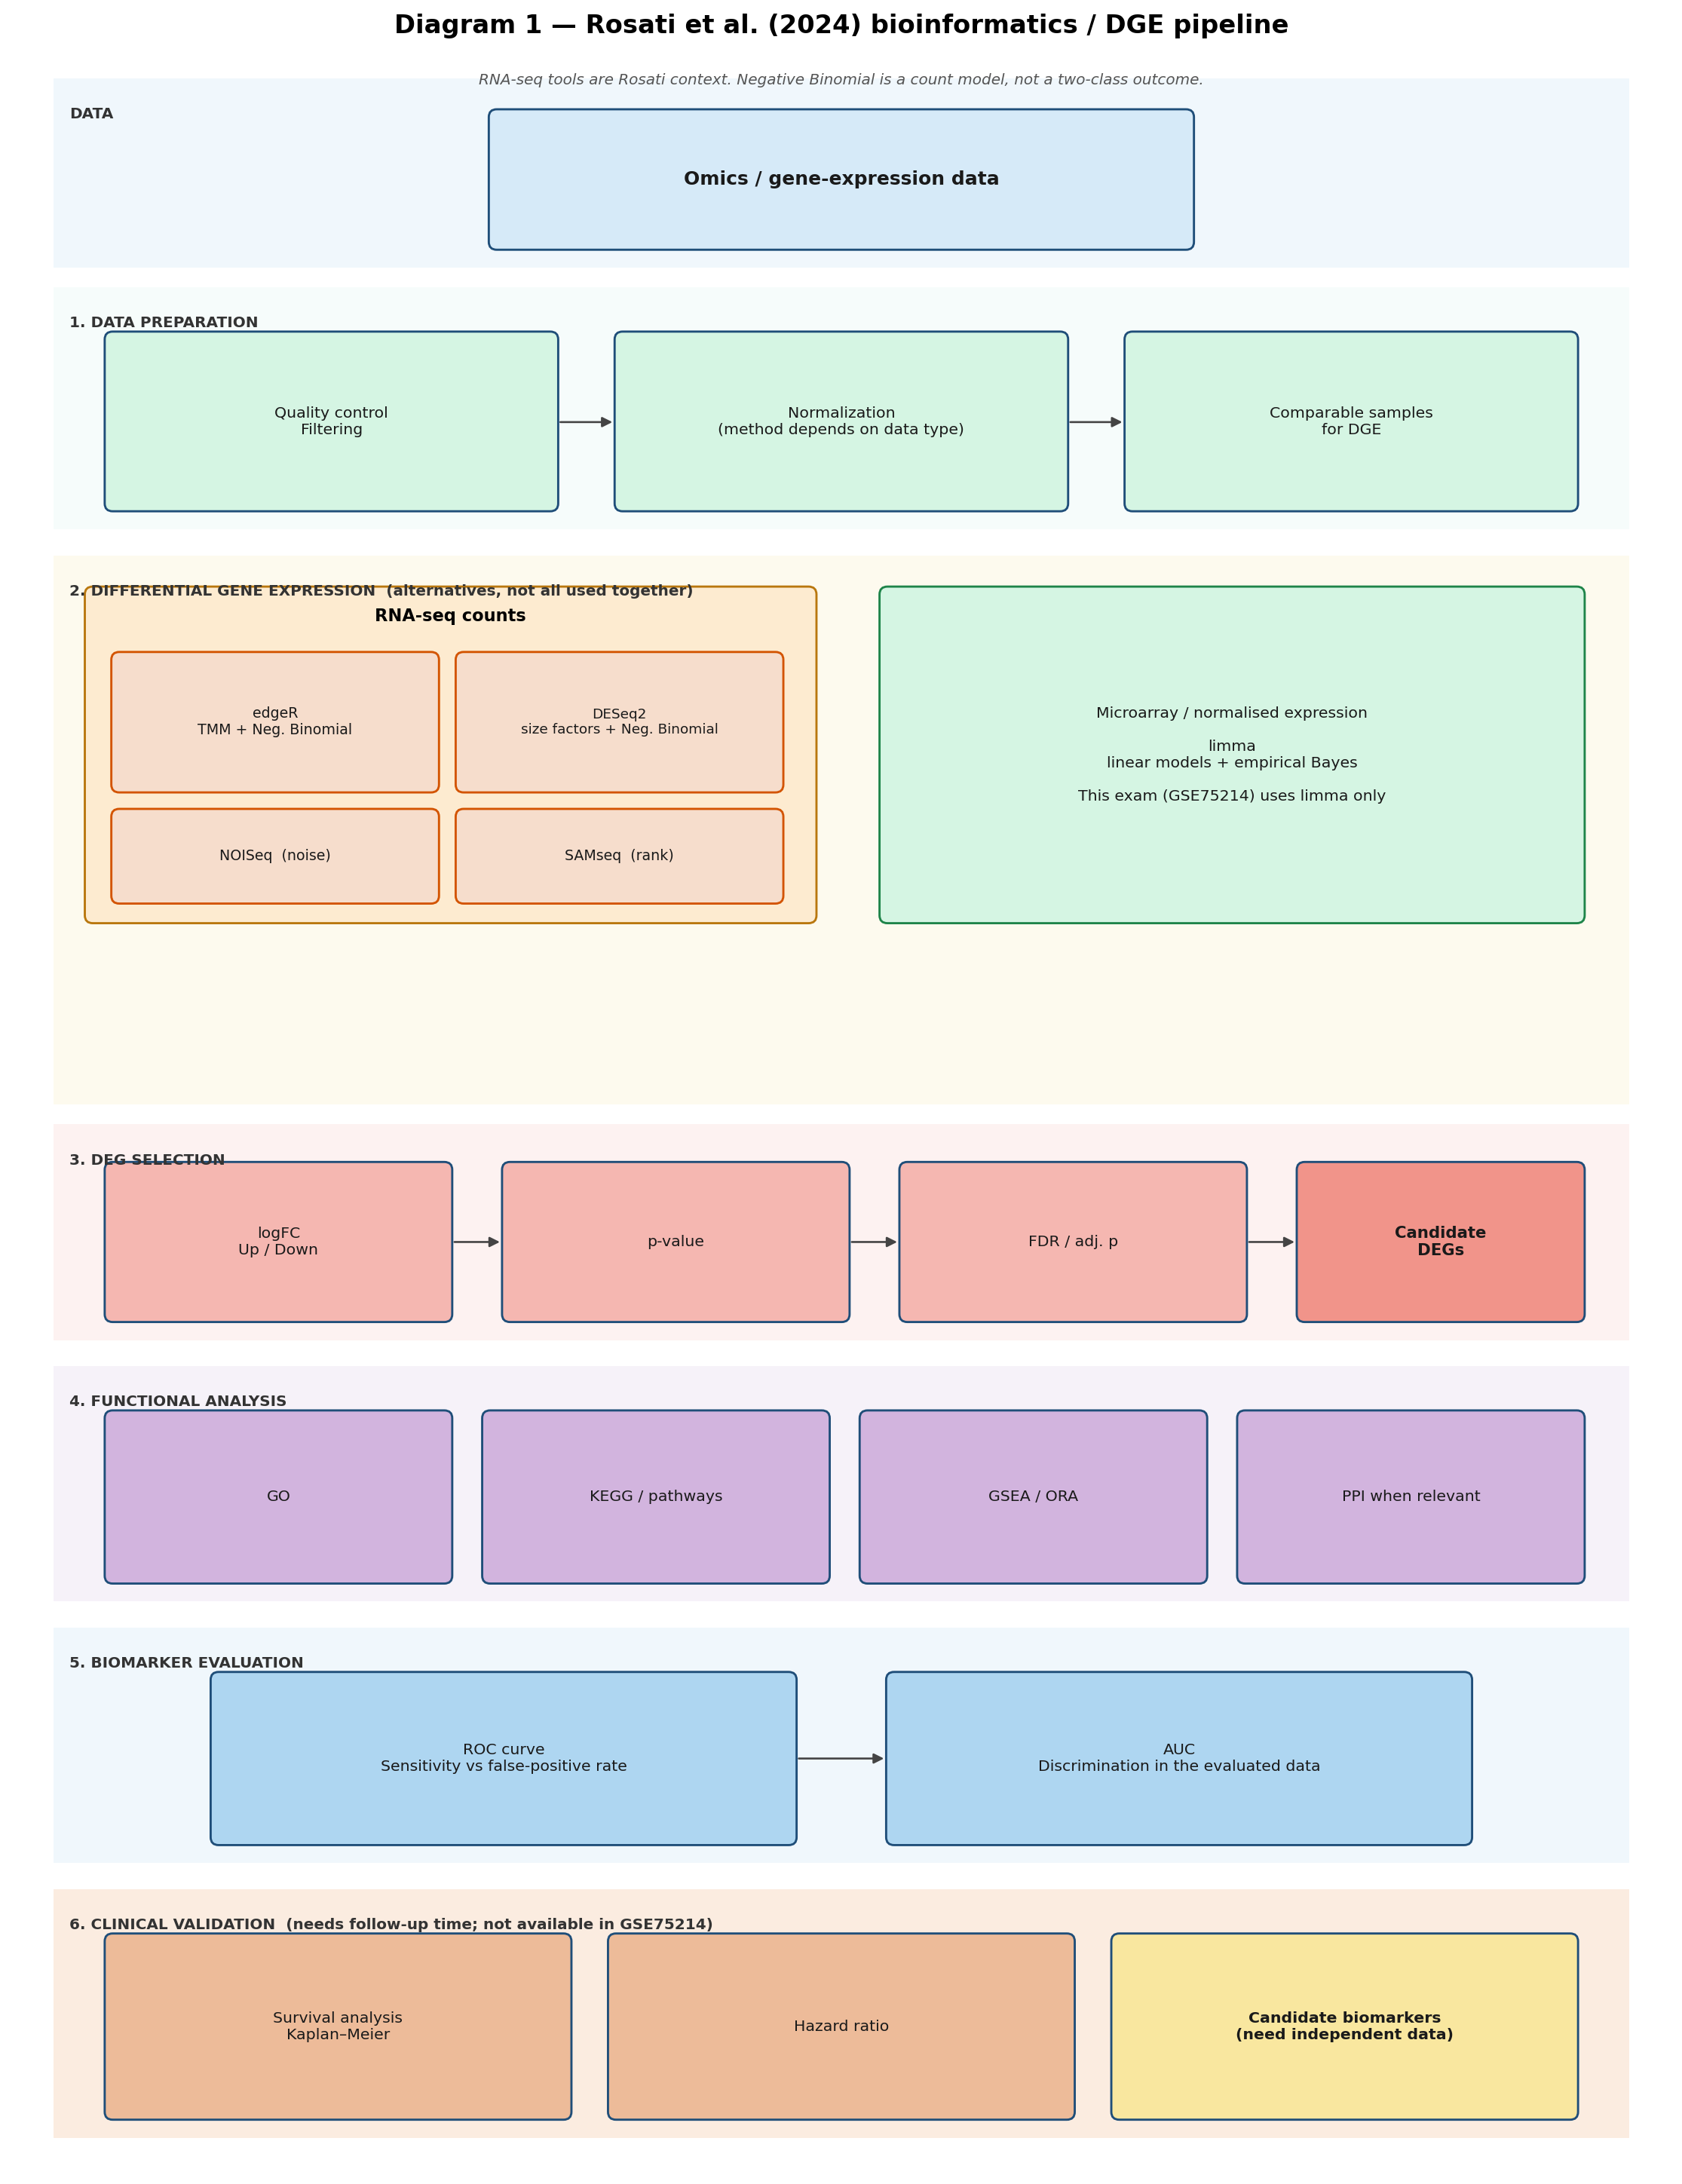

In [6]:
show_fig(FIG / "diagram1_rosati_dge_pipeline.png", width=620)


Diagram 1 moves from normalization to a differential expression model, to the
DEG cutoffs, to visualization, to pathway enrichment, and ends with ROC and survival. Each
box maps to a section of the Rosati review, so it is the map for Task 2.1 and Task 2.2.

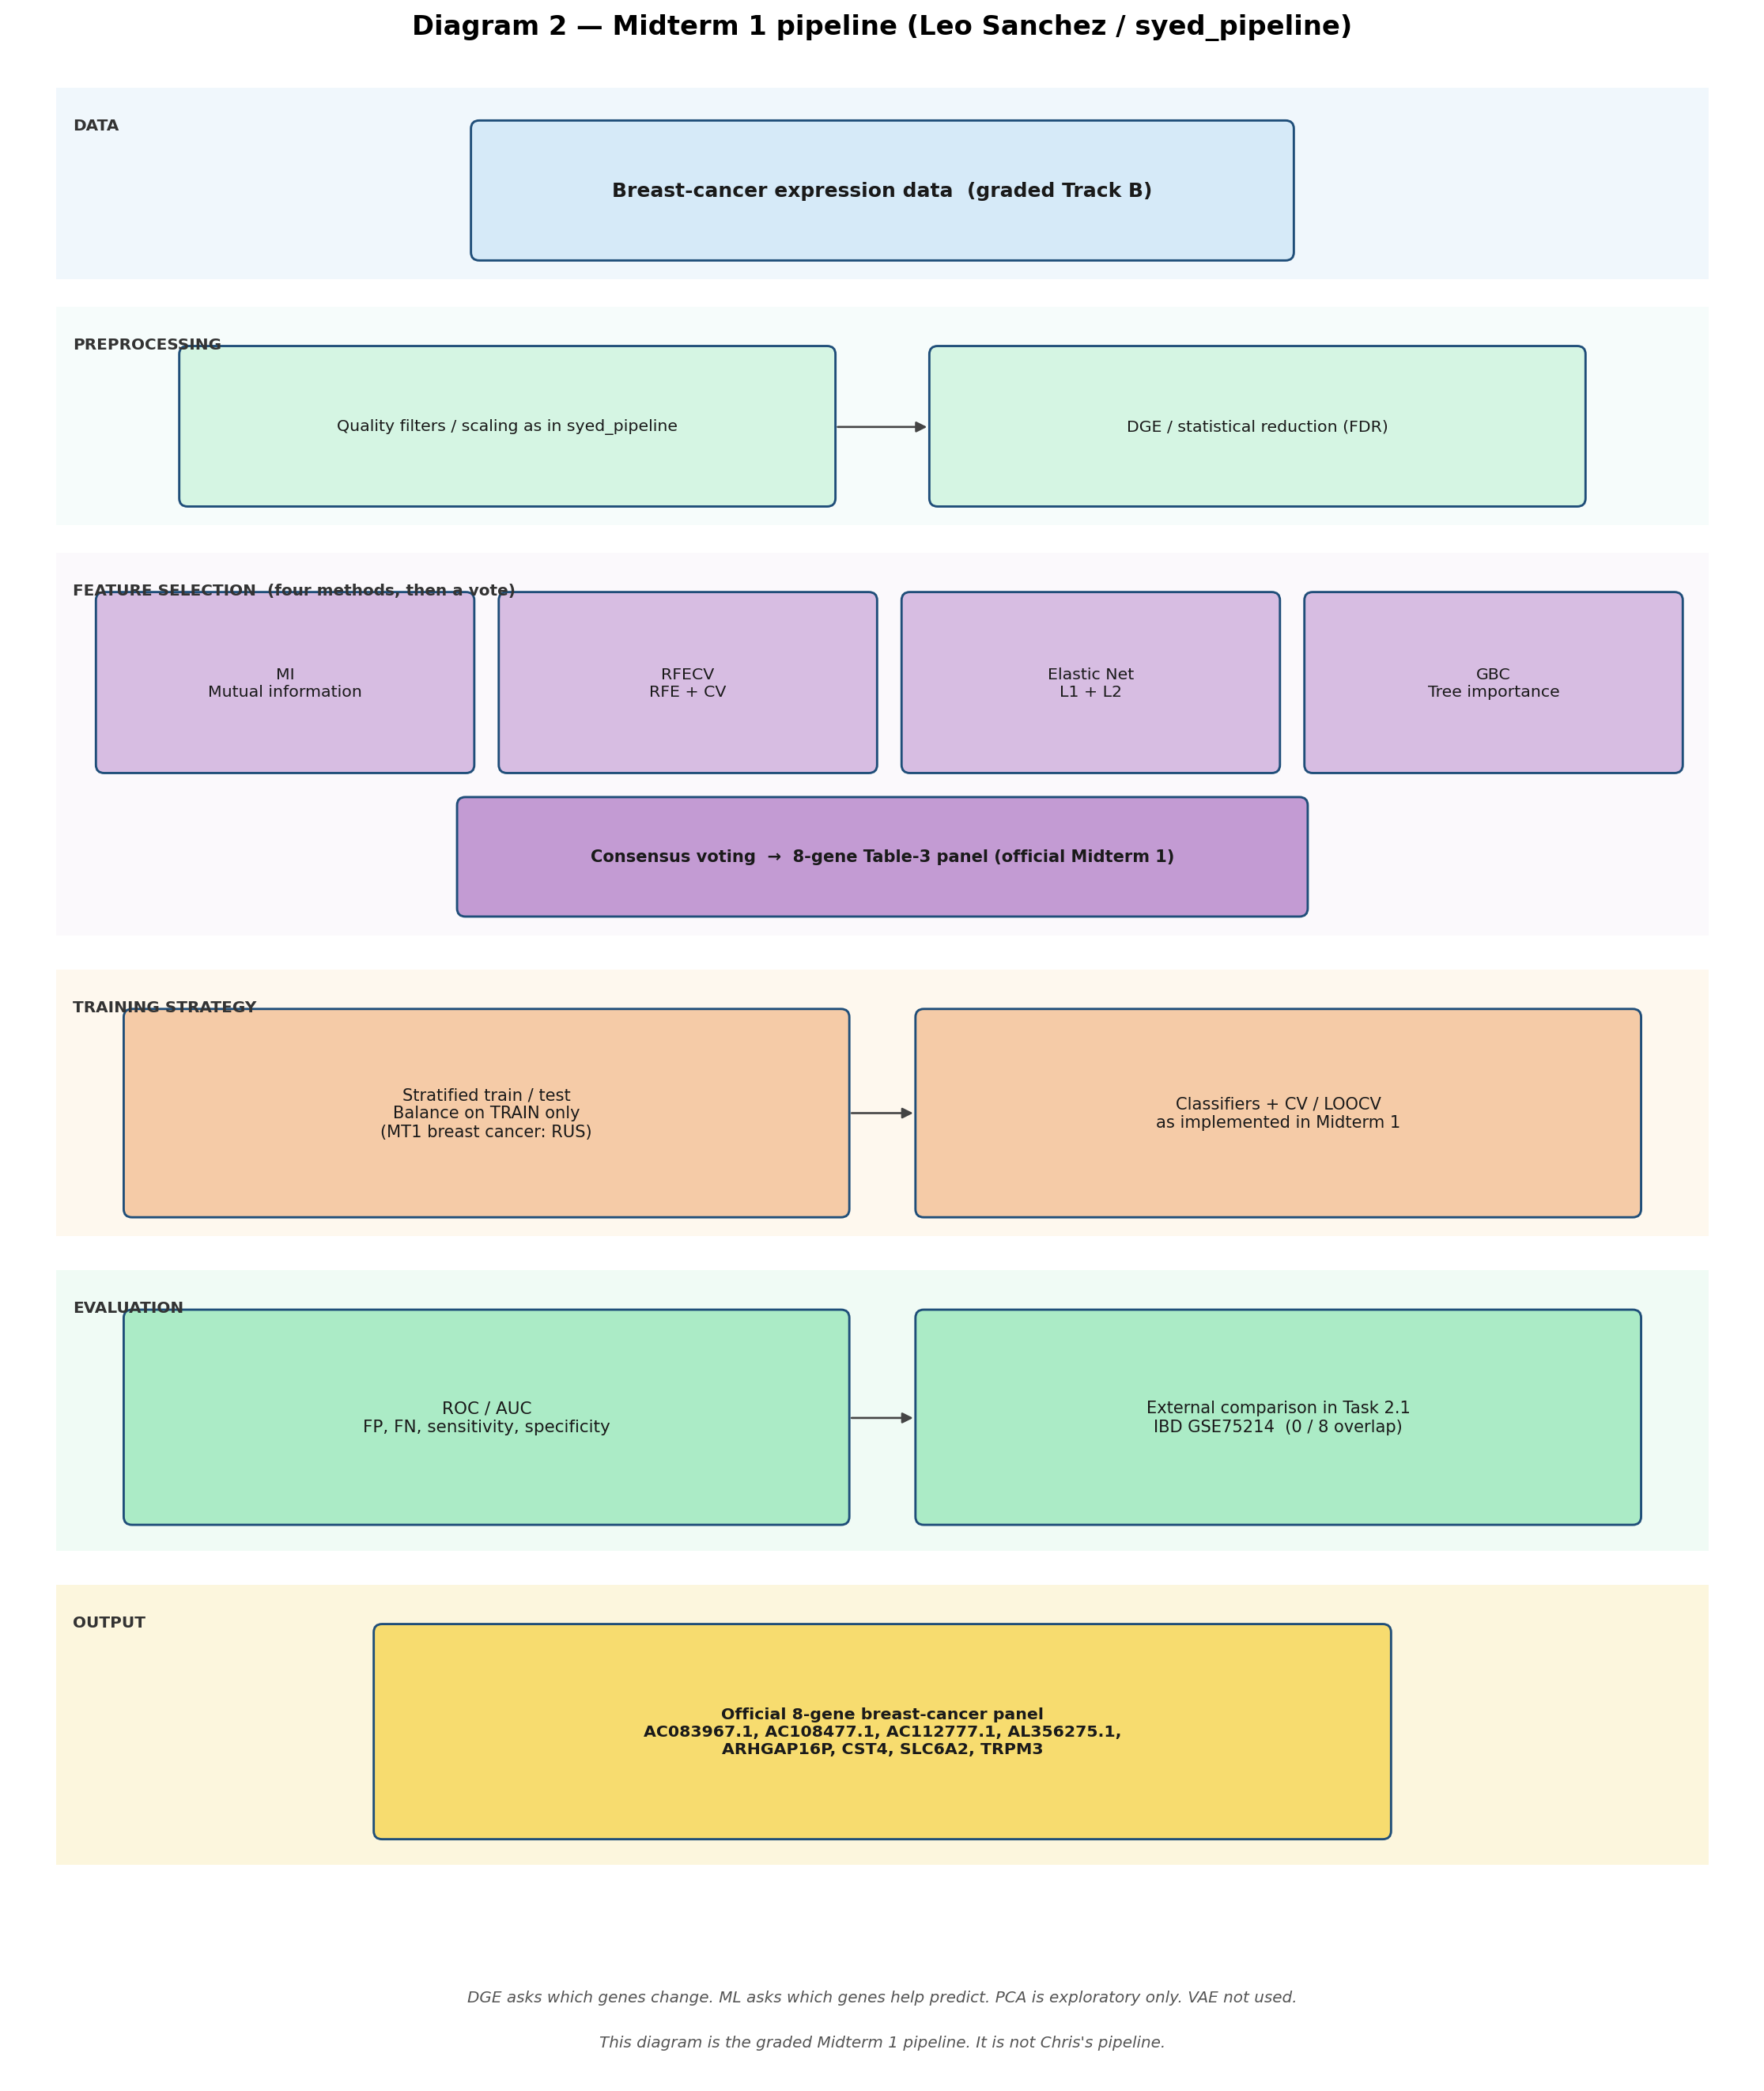

In [7]:
show_fig(FIG / "diagram2_midterm1_ml_pipeline.png", width=620)


Diagram 2 runs on the Midterm 1 breast cancer set, with GSE75214 as the Question
3 validation cohort. It selects genes by their contribution to a classifier, which is the
opposite of the significance test in Diagram 1. Task 2.1 runs both ideas on the same IBD data
so the two can be compared fairly.

### Syed et al. (2024) — reference workflow (Midterm 1 / Diagram 2)

The figure below is the **published Syed IBD biomarker workflow** (GEO75214 discovery cohort;
GEO10616 and GEO36807 validation). Midterm 1 replicated this as `syed_pipeline`: DEG filtering,
four feature-selection methods (MI, RFECV, elastic net, gradient boosting) combined by **union**,
then classifier training and independent validation. Diagram 2 in this exam is the same ML idea
applied to breast cancer with GSE75214 as external validation — not a duplicate of Rosati DGE.

**Reference only** — our executed IBD numbers (535 DEGs, 16-gene ML panel, LDA CV AUC 0.9948)
come from the notebooks in this folder, not from copying Syed’s six-gene panel.


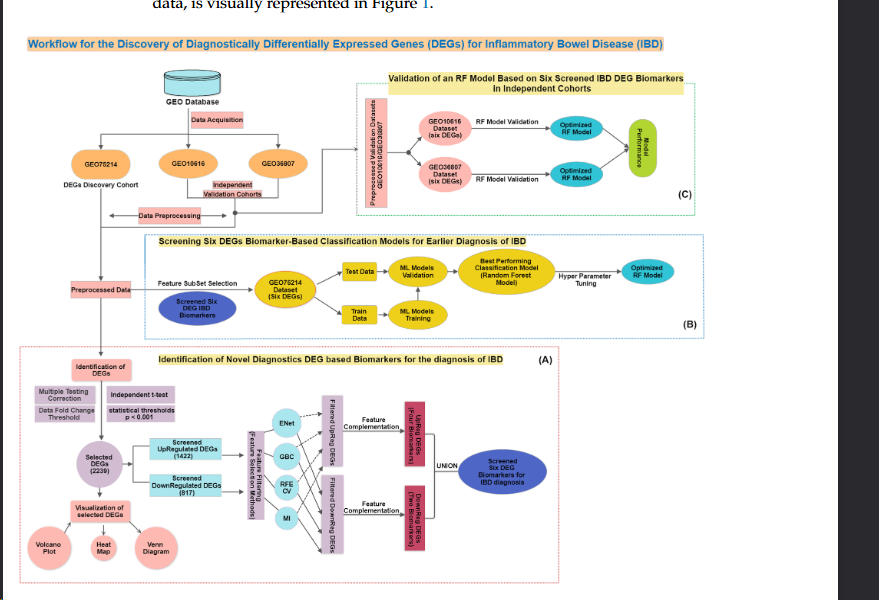

In [8]:
show_fig(FIG / "syed_pipeline_reference.png", width=720)


# Task 2.1 Biomarkers in GSE75214 (inflammatory bowel disease)

The dataset is 172 disease against 22 control, log2 microarray on the GPL6244 platform.
We ran the Rosati differential expression pipeline, then the Midterm 1 machine learning
pipeline with SMOTE balancing, then evaluated and compared them.

### Differential expression result

DEGs at FDR < 0.05 and |log2FC| >= 1.0: 535  (up 323, down 212)

,log2FC,FDR,direction
gene,,,
SLC6A14,4.5331,0.0,up
DUOX2,4.0973,0.0,up
MMP3,3.5576,0.0,up
DUOXA2,3.3827,0.0,up
MMP1,3.2628,0.0,up
LCN2,3.2448,0.0,up
IDO1,3.0622,0.0,up
S100A8,2.9457,0.0,up


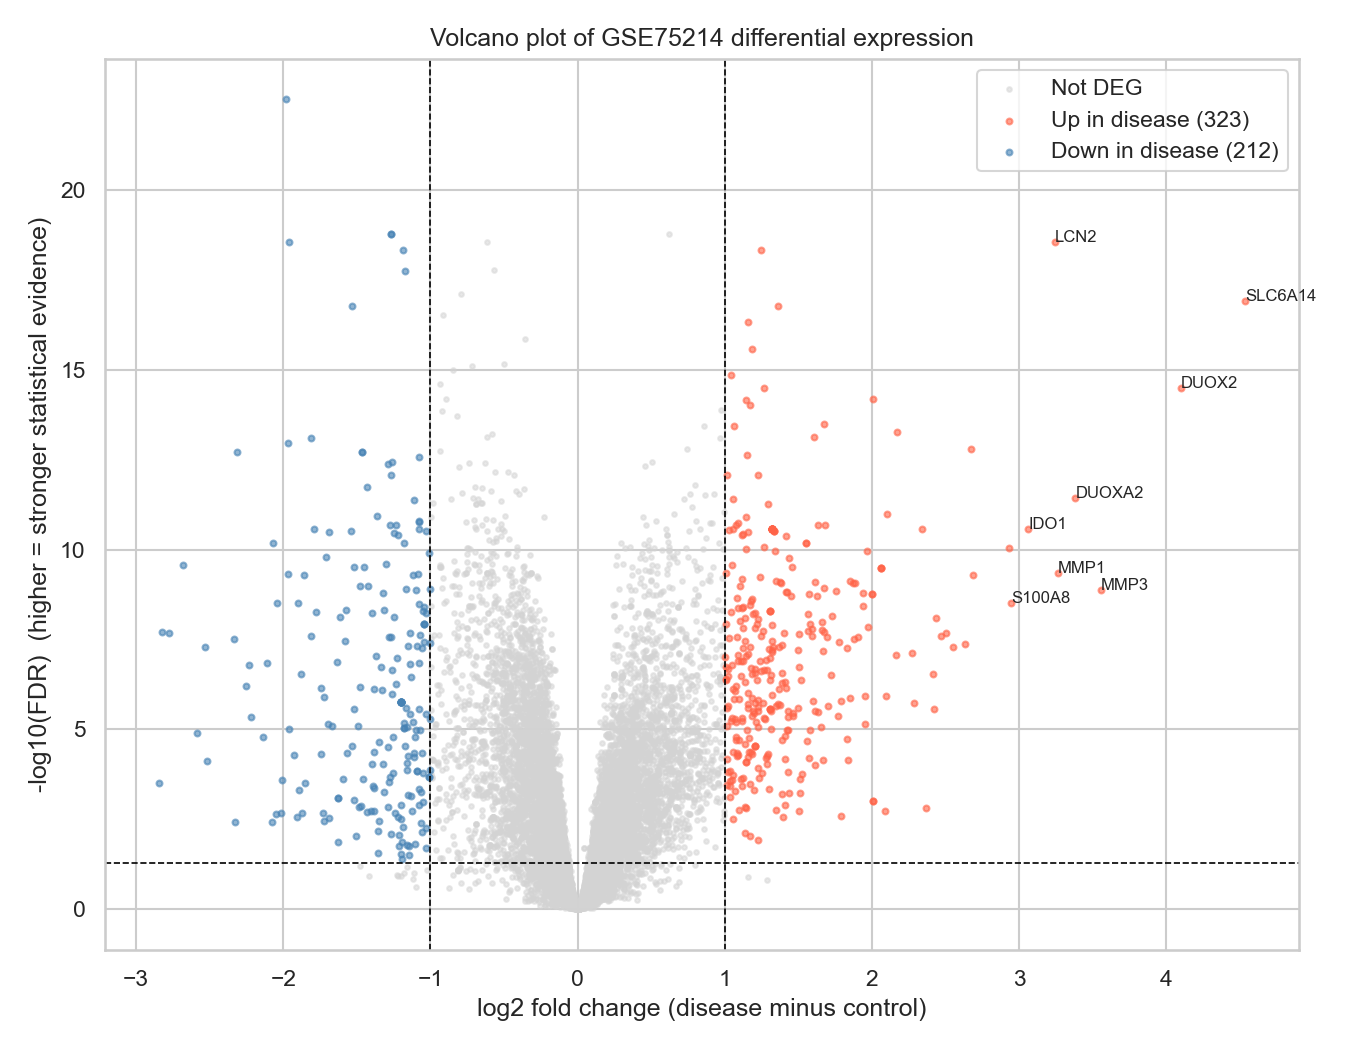

In [9]:
dge1 = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
n_deg = int(dge1["DEG"].sum())
n_up = int((dge1["DEG"] & (dge1["direction"] == "up")).sum())
n_down = int((dge1["DEG"] & (dge1["direction"] == "down")).sum())
print(f"DEGs at FDR < 0.05 and |log2FC| >= 1.0: {n_deg}  (up {n_up}, down {n_down})")
top = dge1[dge1["DEG"]].reindex(dge1[dge1["DEG"]]["log2FC"].abs().sort_values(ascending=False).index)
display(top[["log2FC", "FDR", "direction"]].head(8).round(4))
show_fig(FIG / "task2_1_volcano.png", width=560)


The pipeline finds 535 DEGs, and the strongest are named inflammatory bowel
disease genes such as SLC6A14, DUOX2, LCN2, and IL1B. Seeing the correct disease genes at
the top is the best sign the statistics are working, because these are the same markers the
clinical literature reports for IBD.

### Single gene ROC (Rosati section 4.1)

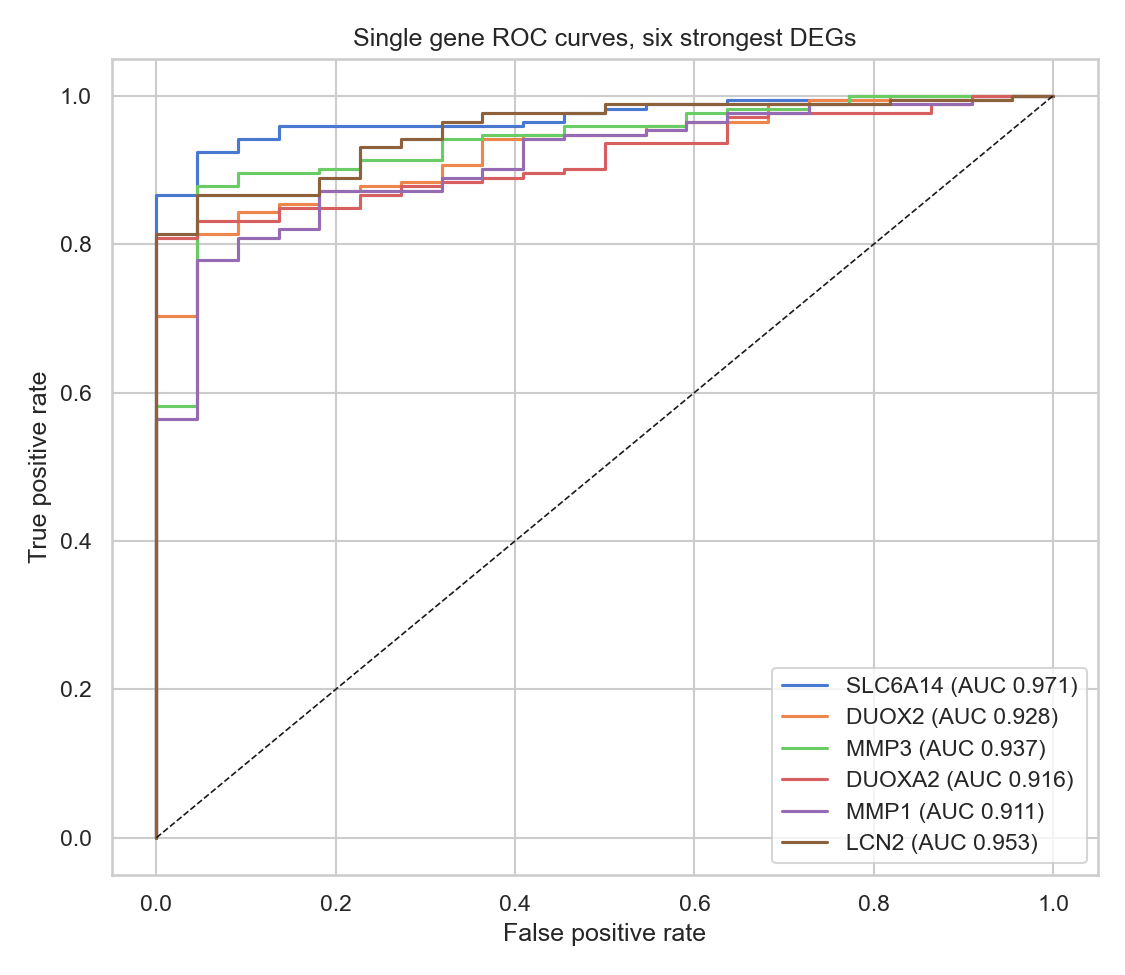

In [10]:
show_fig(FIG / "task2_1_roc_single.png", width=560)


Several strong DEGs also have high single-gene AUC in this dataset. That
shows discriminatory potential here. It is not a clinical validation.


### Machine learning panel and the balance issue

In [11]:
ml1 = pd.read_csv(OUT / "ml_biomarkers_2_1.csv", index_col=0)
print("Machine learning panel size:", len(ml1))
print("Genes chosen by 3 or more methods:", int((ml1["n_methods"] >= 3).sum()))
display(ml1.round(3))

Machine learning panel size: 16
Genes chosen by 3 or more methods: 6


,log2FC,FDR,direction,n_methods,MI,RFECV,ElasticNet,GBC
gene,,,,,,,,
IFITM3,1.243,0.000,up,3,True,False,True,True
CNTFR,-1.984,0.000,down,3,True,False,True,True
PDZK1IP1,1.631,0.000,up,3,True,False,True,True
BACE2,1.364,0.000,up,3,True,True,True,False
SLC6A14,4.533,0.000,up,3,True,False,True,True
STXBP1,1.062,0.000,up,3,False,True,True,True
PAQR5,-1.960,0.000,down,2,True,False,False,True
SLC38A4,-1.531,0.000,down,2,True,False,True,False
TIMP1,2.173,0.000,up,2,True,False,False,True


The next figure puts ML votes on the DGE volcano. Grey = no TOPN vote. Darker blue = more methods.


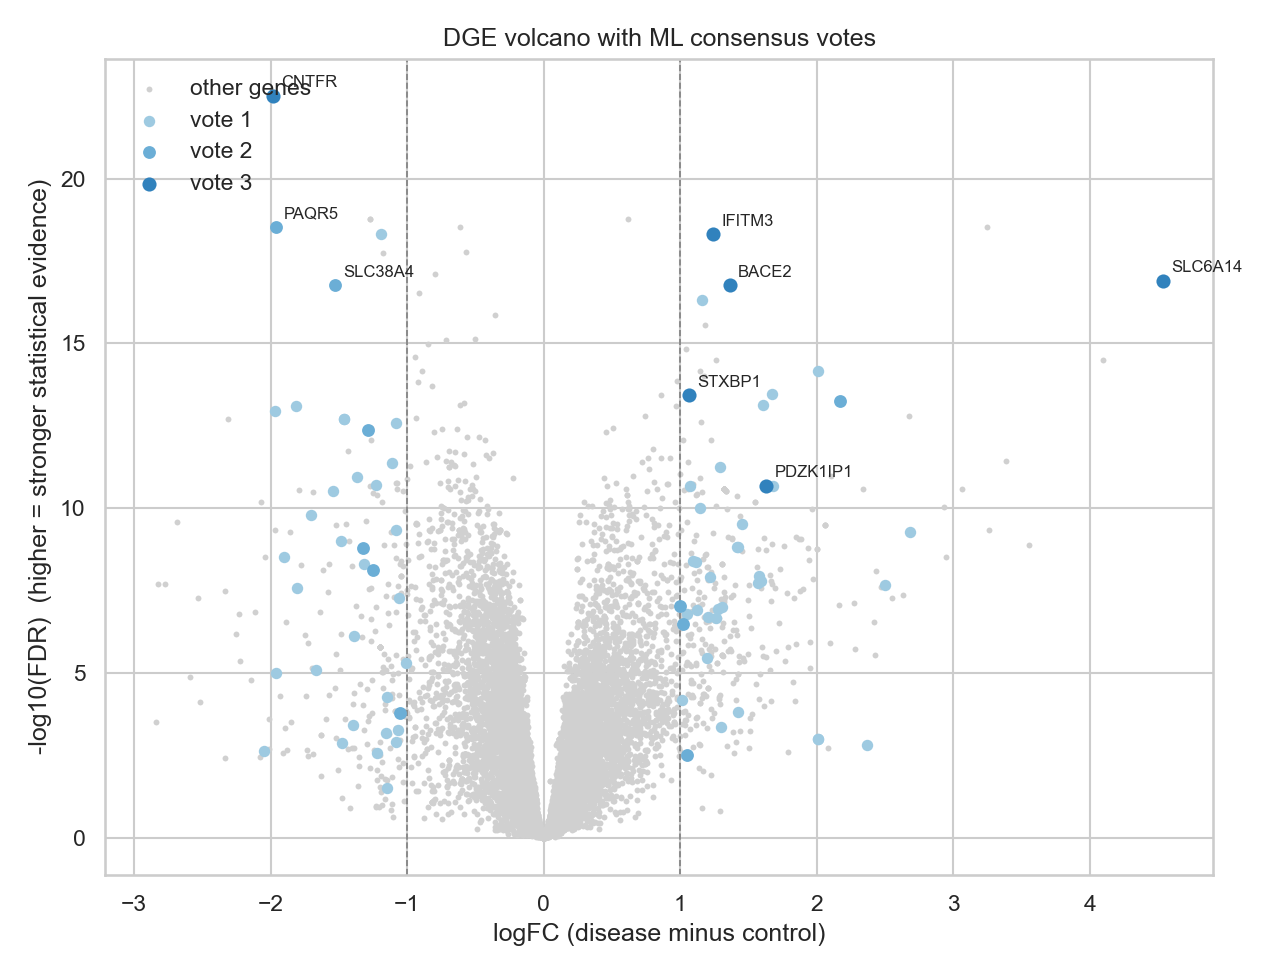

In [12]:
volc = FIG / "task2_1_ml_consensus_volcano.png"
if volc.exists():
    show_fig(volc, width=560)
else:
    print("Run Notebook 2 to create the ML consensus volcano.")


The four-method vote gives a compact ML panel. The size is printed from
`ml_biomarkers_2_1.csv` / `report_data.json` (do not use an old 36-gene figure). SMOTE
was used only in training. Zero overlap with the 8 Midterm 1 genes is expected: that
panel is from breast cancer, not IBD.


### Enrichment and the panel comparison

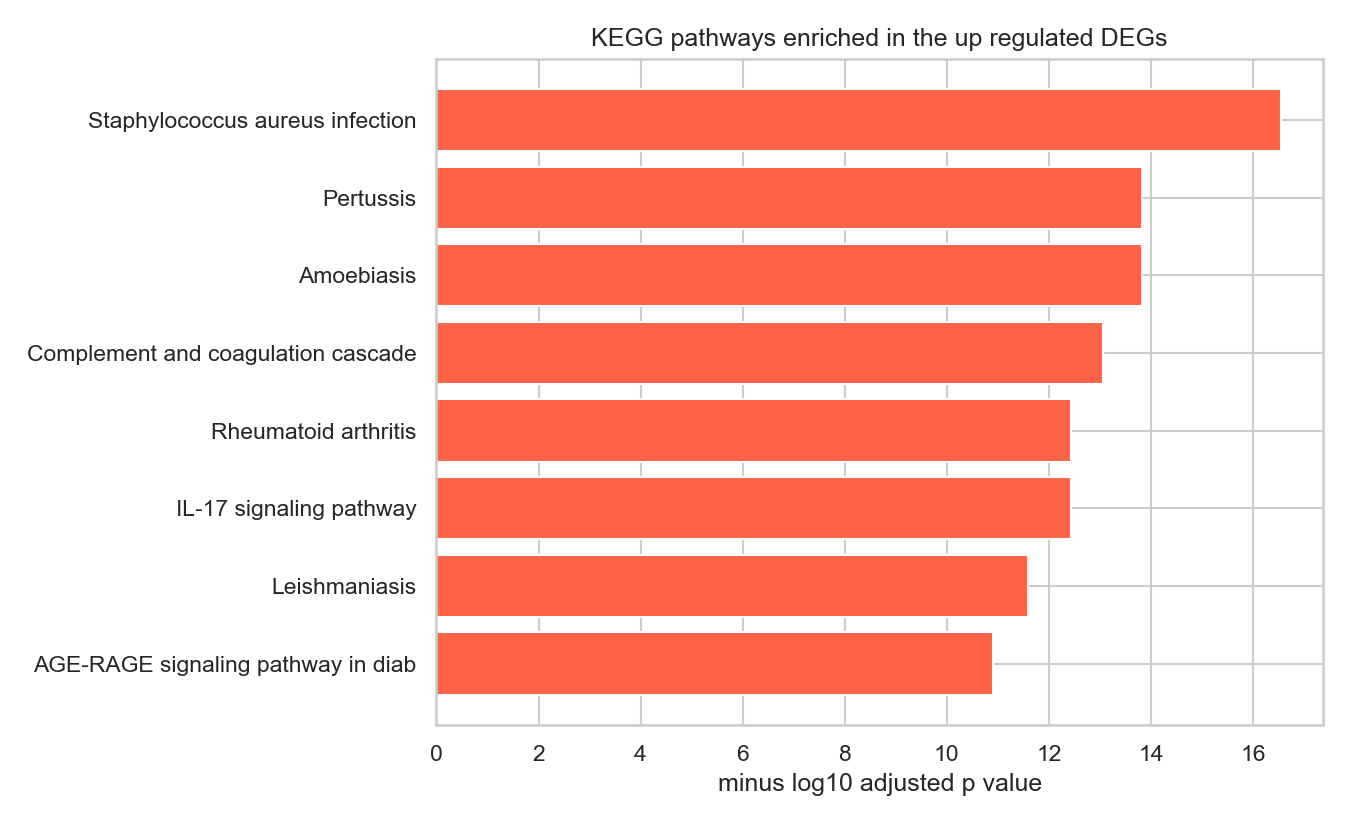

,comparison,shared,out_of
0,Machine learning within statistics panel,6,16
1,Machine learning within Midterm 1 panel,0,16
2,Statistics within Midterm 1 panel,0,8
3,Midterm 1 genes present in GSE75214,3,8


In [13]:
show_fig(FIG / "task2_1_enrichment.png", width=560)
cmp1 = pd.read_csv(OUT / "panel_comparison_2_1.csv")
display(cmp1)

Enrichment maps the up genes onto IL-17 signalling and other immune pathways,
which is the core biology of IBD. The comparison table is the key result of Task 2.1. The
statistics panel and the machine learning panel share 15 genes, so the two methods agree,
but the Midterm 1 breast cancer panel does not transfer, since none of its 8 genes is
an IBD DEG. A biomarker panel is specific to its disease.

## Top 15 UP / Top 15 DOWN (GSE75214 + cervical)

Full code: `2_1_01_data_and_dge.ipynb` and `2_2_02_validate_pipelines.ipynb`.
Genes in the ML panel are flagged in `in_ML_panel`.


In [14]:
import matplotlib.pyplot as plt
import numpy as np

dge1 = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
dge2 = pd.read_csv(OUT / "cervical_dge_table.csv", index_col=0)
deg_mask1 = dge1["DEG"] == True
deg_mask2 = (dge2["FDR"] < 0.05) & (dge2["log2FC"].abs() >= 1.5)

def top15_tables(dge, deg_mask, ml_genes):
    deg = dge[deg_mask].copy()
    up = deg[deg["direction"] == "up"].sort_values("log2FC", ascending=False).head(15)
    down = deg[deg["direction"] == "down"].sort_values("log2FC", ascending=True).head(15)
    ml_set = set(ml_genes)
    def mark(df):
        out = df[["log2FC", "FDR"]].copy()
        out.index.name = "gene"
        out["in_ML_panel"] = [g in ml_set for g in out.index]
        return out.round(4)
    return mark(up), mark(down)

ml1 = pd.read_csv(OUT / "ml_biomarkers_2_1.csv")["gene"].tolist()
ml2 = pd.read_csv(OUT / "cervical_ml_panel.csv")["gene"].tolist()
up21, down21 = top15_tables(dge1, deg_mask1, ml1)
up22, down22 = top15_tables(dge2, deg_mask2, ml2)

print("GSE75214 — Top 15 UP (DEG, FDR<0.05, |log2FC|≥1)  |  genes in ML panel highlighted")
display(up21)
print("GSE75214 — Top 15 DOWN")
display(down21)
print("Cervical merged — Top 15 UP")
display(up22)
print("Cervical merged — Top 15 DOWN")
display(down22)

overlap_up = sorted(set(up21.index) & set(up22.index))
overlap_down = sorted(set(down21.index) & set(down22.index))
print(f"Genes in top-15 UP of both tasks: {overlap_up}")
print(f"Genes in top-15 DOWN of both tasks: {overlap_down}")


GSE75214 — Top 15 UP (DEG, FDR<0.05, |log2FC|≥1)  |  genes in ML panel highlighted


,log2FC,FDR,in_ML_panel
gene,,,
SLC6A14,4.5331,0.0,True
DUOX2,4.0973,0.0,False
MMP3,3.5576,0.0,False
DUOXA2,3.3827,0.0,False
MMP1,3.2628,0.0,False
LCN2,3.2448,0.0,False
IDO1,3.0622,0.0,False
S100A8,2.9457,0.0,False
IL1B,2.9344,0.0,False


GSE75214 — Top 15 DOWN


,log2FC,FDR,in_ML_panel
gene,,,
MEP1B,-2.8415,0.0003,False
TMIGD1,-2.8216,0.0000,False
ABCG2,-2.7745,0.0000,False
CYP2B6,-2.6850,0.0000,False
UGT2A3,-2.5901,0.0000,False
HMGCS2,-2.5320,0.0000,False
SLC13A1,-2.5163,0.0001,False
SLC26A2,-2.3353,0.0000,False
CYP3A4,-2.3296,0.0038,False


Cervical merged — Top 15 UP


,log2FC,FDR,in_ML_panel
gene,,,
SPP1,3.7418,0.0,False
SYCP2,3.5861,0.0,True
CDKN2A,3.5719,0.0,True
CXCL8,3.5600,0.0,True
MMP12,3.3757,0.0,False
MMP1,3.2154,0.0,False
INHBA,3.0640,0.0,True
IFI44L,2.8616,0.0,False
AIM2,2.8498,0.0,True


Cervical merged — Top 15 DOWN


,log2FC,FDR,in_ML_panel
gene,,,
CRNN,-7.0438,0.0,True
CRISP3,-5.3675,0.0,False
MAL,-5.3654,0.0,False
KRT1,-5.3060,0.0,False
SLURP1,-4.7087,0.0,False
CRCT1,-4.5625,0.0,False
ENDOU,-4.5186,0.0,False
ALOX12,-4.4149,0.0,False
UPK1A,-4.3903,0.0,False


Genes in top-15 UP of both tasks: ['MMP1', 'MMP12']
Genes in top-15 DOWN of both tasks: []


## Heatmap modules (Task 2.1)


In [15]:
mods = pd.read_csv(OUT / "task2_1_heatmap_gene_modules.csv")
print("Heatmap gene modules (from 2_1_01 clustering):")
for module_id, grp in mods.groupby("module"):
    genes = grp["gene"].tolist()
    print(f"Module {module_id} ({len(genes)} genes): {', '.join(genes)}")
display(mods)


Heatmap gene modules (from 2_1_01 clustering):
Module 1 (11 genes): SLC13A1, PRKG2, MEP1B, CYP3A4, CYP2B6, UGT2A3, ABCG2, ABCB1, PCK1, TMIGD1, GUCA2A
Module 2 (4 genes): MT1M, AQP8, HMGCS2, SLC26A2
Module 3 (24 genes): IDO1, MMP12, CHI3L1, TIMP1, CXCL1, KYNU, MMP3, MMP1, PTGS2, S100A8, AQP9, IL1B, CXCL8, MUC1, TNIP3, MMP7, TCN1, VSIG1, NOS2, SAA2, SLC6A14, LCN2, DUOX2, DUOXA2
Module 4 (1 genes): REG1B


,gene,cluster_position,module,log2FC,FDR,direction
0,SLC13A1,1,1,-2.516310,7.772739e-05,down
1,PRKG2,2,1,-2.252457,6.392515e-07,down
2,MEP1B,3,1,-2.841531,2.998035e-04,down
3,CYP3A4,4,1,-2.329615,3.845510e-03,down
4,CYP2B6,5,1,-2.685003,2.695643e-10,down
5,UGT2A3,6,1,-2.590060,1.280849e-05,down
6,ABCG2,7,1,-2.774521,2.028751e-08,down
7,ABCB1,8,1,-2.110422,1.397253e-07,down
8,PCK1,9,1,-2.220152,4.402362e-06,down
9,TMIGD1,10,1,-2.821645,1.931112e-08,down


## Model comparison summary (Task 2.1)

One table combining **5-fold CV ROC-AUC** (LDA, logistic regression, random forest on both panels)
with **80/20 hold-out** metrics (Accuracy, Precision, Recall, F1) for LDA/LR/RF and WELM/BWELM
on the ML panel (same train/test split as feature selection).

CV rows report ROC-AUC only; hold-out rows include Precision (e.g. LDA shrinkage baseline).
The LDA teaching plot (LD1 boxplot) is a visual check on the 16-gene ML panel — numbers come from this table.
Built in `2_1_03_evaluation_and_comparison.ipynb` → `model_comparison_summary_2_1.csv`.


In [16]:
summary_path = OUT / "model_comparison_summary_2_1.csv"
if not summary_path.exists():
    print("Run 2_1_03_evaluation_and_comparison.ipynb to generate model_comparison_summary_2_1.csv")
else:
    unified = pd.read_csv(summary_path)
    print("Task 2.1 model comparison (CV + hold-out):")
    display(unified.round(4))


Task 2.1 model comparison (CV + hold-out):


,panel,model,evaluation,ROC-AUC,SD,Accuracy,Precision,Recall,F1,Notes
0,Statistics panel (158),LDA (linear baseline),5-fold CV (SMOTE inside folds),0.9821,0.0323,NaN,NaN,NaN,NaN,"linear baseline, shrinkage"
1,Statistics panel (158),Logistic Regression,5-fold CV (SMOTE inside folds),0.9942,0.0071,NaN,NaN,NaN,NaN,"linear, class weight"
2,Statistics panel (158),Random Forest,5-fold CV (SMOTE inside folds),0.9832,0.0086,NaN,NaN,NaN,NaN,"trees, class weight"
3,Machine learning panel (16),LDA (linear baseline),5-fold CV (SMOTE inside folds),0.9948,0.0052,NaN,NaN,NaN,NaN,"linear baseline, shrinkage"
4,Machine learning panel (16),Logistic Regression,5-fold CV (SMOTE inside folds),0.9948,0.0064,NaN,NaN,NaN,NaN,"linear, class weight"
5,Machine learning panel (16),Random Forest,5-fold CV (SMOTE inside folds),0.9907,0.0077,NaN,NaN,NaN,NaN,"trees, class weight"
6,Machine learning panel (16),WELM,80/20 hold-out,0.9857,NaN,0.8974,1.0,0.8857,0.9394,imbalance-aware ELM (teamwork reuse)
7,Machine learning panel (16),BWELM,80/20 hold-out,0.9357,NaN,0.8974,1.0,0.8857,0.9394,imbalance-aware ELM (teamwork reuse)
8,Machine learning panel (16),LDA (linear baseline),80/20 hold-out (SMOTE on train),0.9714,NaN,0.8974,1.0,0.8857,0.9394,same split as WELM; linear baseline shrinkage ...
9,Machine learning panel (16),Logistic Regression,80/20 hold-out (SMOTE on train),0.9857,NaN,0.9487,1.0,0.9429,0.9706,same split as WELM; linear baseline shrinkage ...


# Task 2.2 Four merged cervical cancer datasets

We merged GSE6791, GSE9750, GSE63514, and GSE67522 across three microarray platforms into one
master set of 179 samples and the shared genes counted in the merge notebook, then validated both pipelines against Wang
et al. (2022) at the cutoff |logFC| >= 1.5 and adjusted p below 0.05.


### The merge

Master matrix: 179 samples × 12,191 genes
Cancer: 101  Normal: 78
By dataset:
          count  cancer
batch                  
GSE63514     52      28
GSE67522     42      20
GSE6791      28      20
GSE9750      57      33


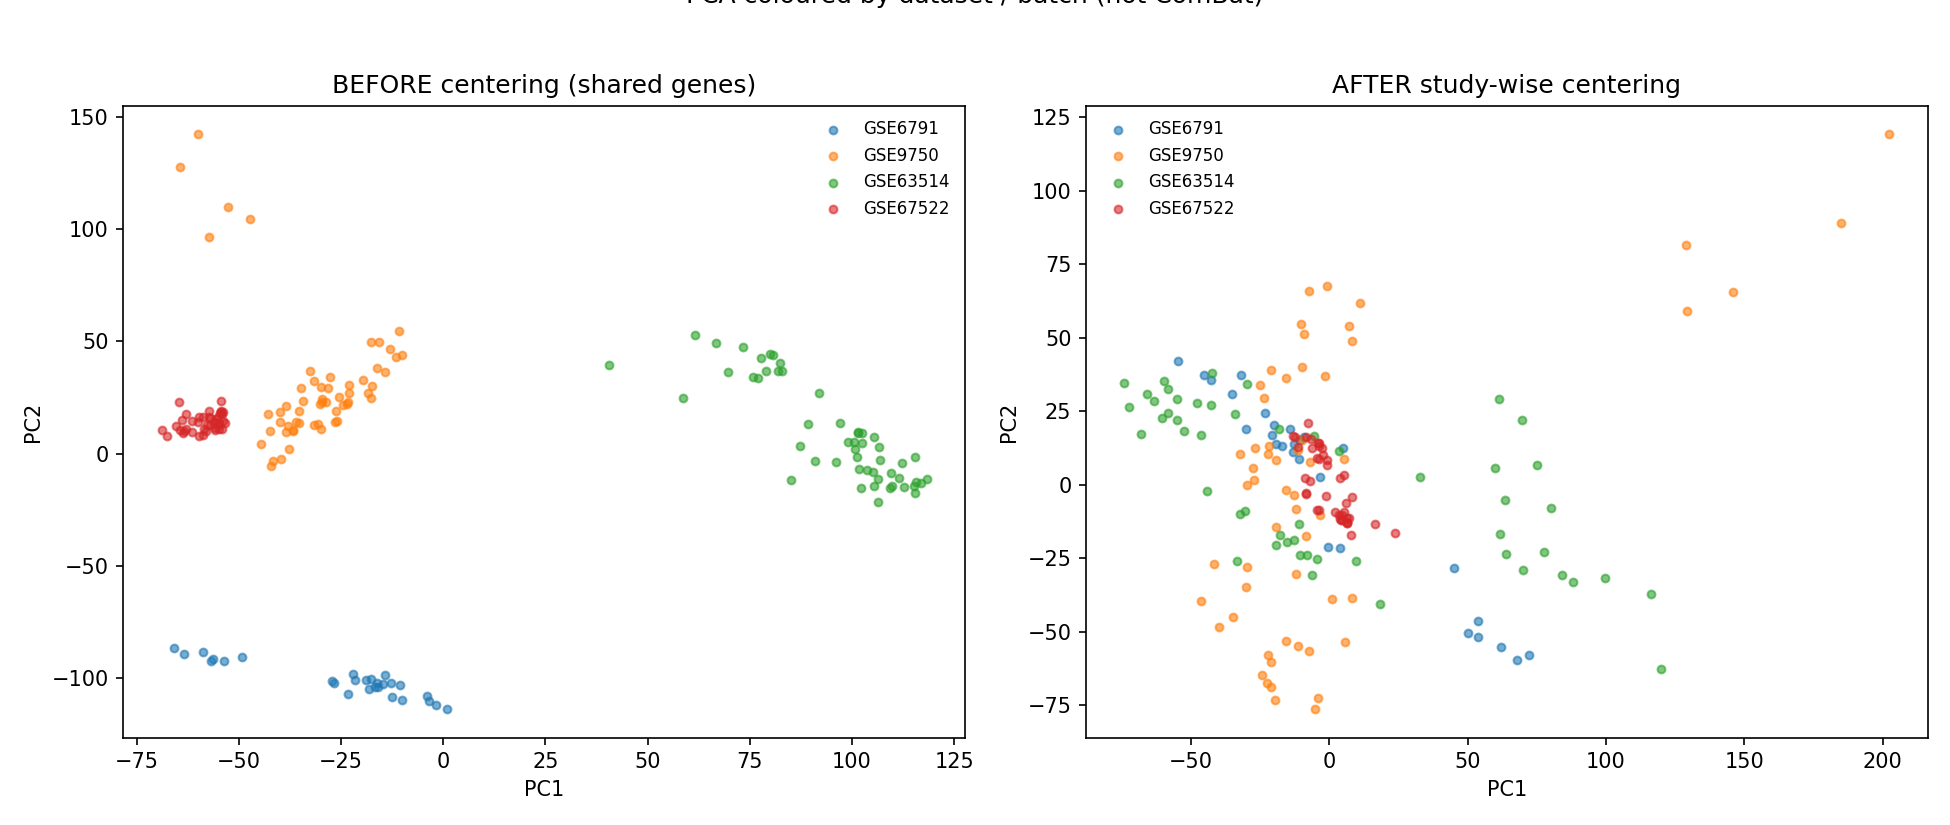

In [17]:
master = pd.read_csv(DATA / "cervical_master.csv")
print(
    "Master matrix:",
    master.shape[0],
    "samples ×",
    f"{master.shape[1] - 2:,}",
    "genes",
)
print("Cancer:", int((master["target"] == 1).sum()), " Normal:", int((master["target"] == 0).sum()))
print("By dataset:")
print(master.groupby("batch")["target"].agg(["count", "sum"]).rename(columns={"sum": "cancer"}))
show_fig(FIG / "task2_2_merge_pca.png", width=760)


In the left PCA the four datasets overlap, which means the per dataset centering
removed most of the platform batch effect. In the right PCA cancer and normal fall on opposite
sides, so the biology survived the merge. This is the check that makes the merged analysis
trustworthy.

### Differential expression and the Wang comparison

Cervical DEGs at |logFC| >= 1.5 and adjP < 0.05: 381
Wang hub genes recovered as DEGs: 10 of 10


,log2FC,FDR,direction,DEG
gene,,,,
CDK1,2.093,0.0,up,True
CDC20,1.845,0.0,up,True
AURKA,2.303,0.0,up,True
TOP2A,1.977,0.0,up,True
ASPM,2.307,0.0,up,True
NCAPG,1.666,0.0,up,True
KIF23,2.110,0.0,up,True
CENPF,1.993,0.0,up,True
KIF20A,2.019,0.0,up,True


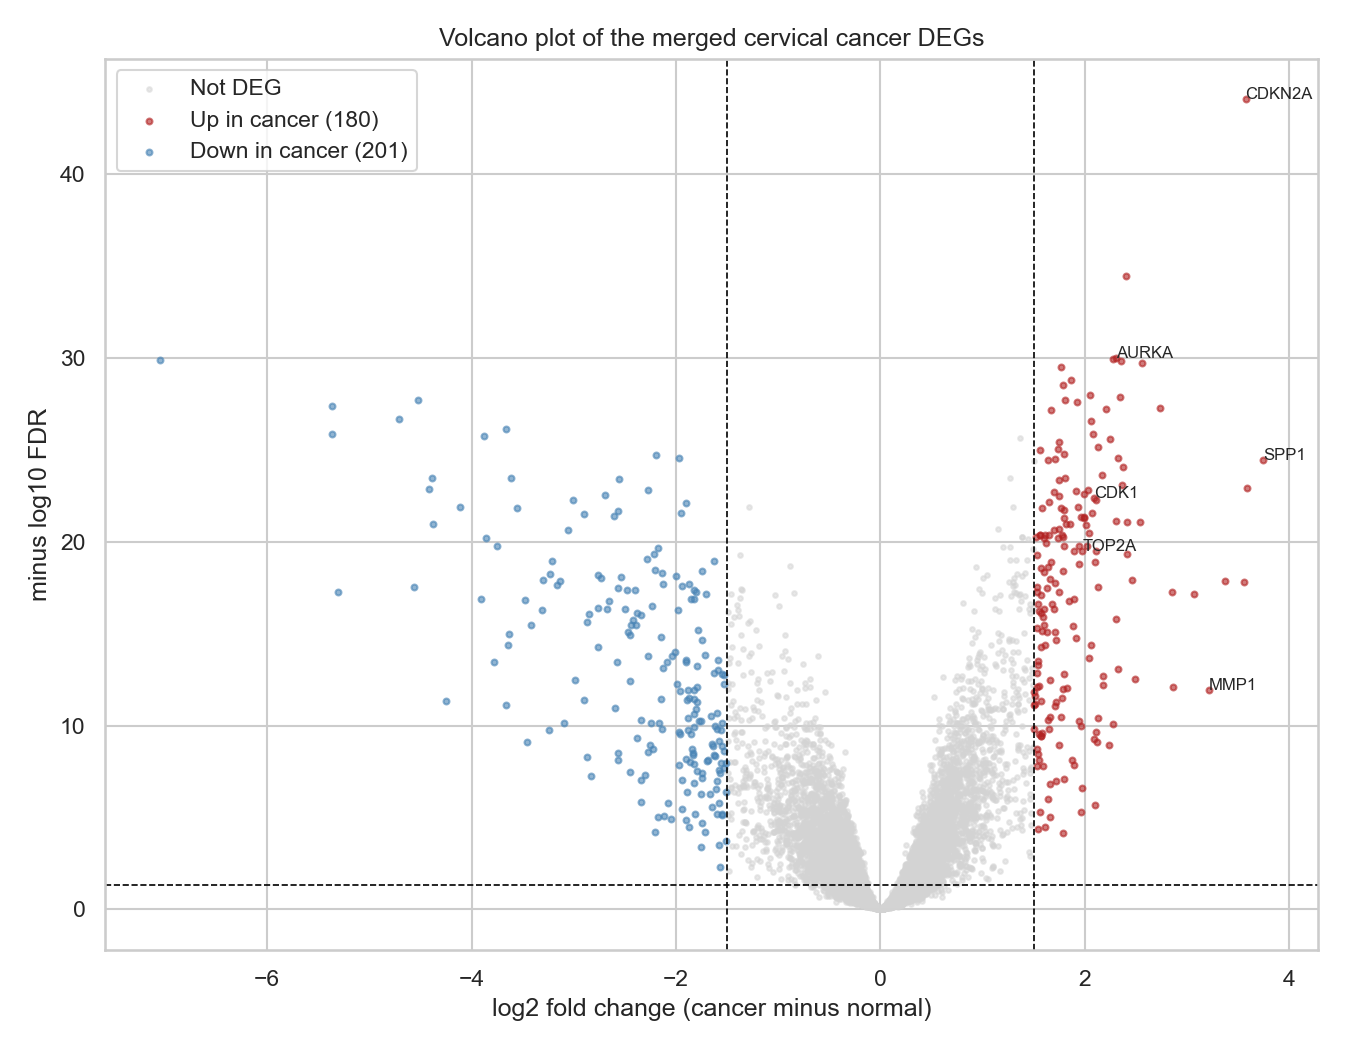

In [18]:
dge2 = pd.read_csv(OUT / "cervical_dge_table.csv", index_col=0)
print("Cervical DEGs at |logFC| >= 1.5 and adjP < 0.05:", int(dge2["DEG"].sum()))
wang_hub = ["CDK1", "CDC20", "AURKA", "TOP2A", "ASPM", "NCAPG", "KIF23", "CENPF", "KIF20A", "PRC1"]
recovered = [g for g in wang_hub if g in dge2.index and dge2.loc[g, "DEG"]]
print("Wang hub genes recovered as DEGs:", len(recovered), "of 10")
display(dge2.reindex(wang_hub)[["log2FC", "FDR", "direction", "DEG"]].round(3))
show_fig(FIG / "task2_2_volcano.png", width=560)


The merge gives 381 DEGs led by CDKN2A, the p16 marker of HPV driven cervical
cancer. All ten hub genes that Wang et al. report are recovered as DEGs, every one upregulated
in cancer. Recovering the whole published hub set from a differently sized merge is strong
external validation of the pipeline.

### Machine learning panel on the merged set

In [19]:
ml2 = pd.read_csv(OUT / "cervical_ml_panel.csv", index_col=0)
print("Machine learning panel size:", len(ml2))
print("AURKA in the panel:", "AURKA" in ml2.index)
display(ml2.round(3))

Machine learning panel size: 47
AURKA in the panel: True


,log2FC,FDR,direction,n_methods
gene,,,,
SMC4,1.921,0.0,up,4
THSD4,-2.690,0.0,down,4
CDKN2A,3.572,0.0,up,4
UBE2C,1.744,0.0,up,4
TACC3,1.744,0.0,up,4
TYMS,2.053,0.0,up,3
TIMELESS,1.784,0.0,up,3
RAD54L,2.207,0.0,up,3
MCM4,1.641,0.0,up,3


The machine learning pipeline cuts the 381 DEGs to a 47 gene panel that reaches
a cross validated AUC near 0.997. The panel keeps AURKA, the single gene Wang et al. tie to
worse survival, so the data driven method lands on their most important marker on its own.

## Oral defense (consolidated)

### Data / EDA
- What are the dimensions of GSE75214 (samples × probes, then samples × genes)?
- How many disease and control samples? Missing values?
- What are the dimensions of each cervical dataset before merge?
- Are rows samples or probes in raw GEO files?

### DGE
- What is logFC? Why separate UP and DOWN?
- What is FDR, and why not raw p-values only?
- Why limma instead of DESeq2 or edgeR for GSE75214?
- What does the volcano show? What can we not conclude?
- Which DEG cutoffs does the exam require?

### Feature selection
- What does MI measure? How does RFECV work (support vs ranking)?
- Why TOPN consensus? Why several FS methods?
- Where is SMOTE applied, and why not before the split?

### Evaluation
- FP vs FN? Sensitivity vs specificity?
- What does AUC mean? How is FDR different from classifier FP/FN?
- What is LDA, and why use it as a baseline?
- Why can AUC near 0.99 still be optimistic?

### Merge / integration
- Why did gene count decrease after merge?
- Why do sample counts differ from Wang?
- Study-wise centering vs ComBat — what did we run?
- Why is Wang 10/10 not an exact replication?
- Why is Midterm 1 overlap zero (not a failed midterm)?


# Conclusion

The Rosati-style DGE step finds genes with a statistically important expression change.
The Syed / Midterm 1 style feature-selection step finds genes that help predict the class.
Together they give a shorter candidate list. High AUC on GSE75214 can still be optimistic
because selection and evaluation use the same cohort. The cervical analysis recovers
10/10 Wang hub genes as external agreement, not as an exact copy of Wang's pipeline.
